In [2]:
import pandas as pd
from collections import Counter

In [6]:
df = pd.read_csv("dataset.csv.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [7]:
df['Cuisines'].head(10)
df['Cuisines'].isnull().sum()  # check for missing values

np.int64(9)

In [8]:
df = df.dropna(subset=['Cuisines'])

In [9]:
# Count exact combinations as they appear (e.g., "North Indian, Chinese")
cuisine_combo_counts = df['Cuisines'].value_counts().head(10)
print("Top 10 most common cuisine combinations:")
print(cuisine_combo_counts)

Top 10 most common cuisine combinations:
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


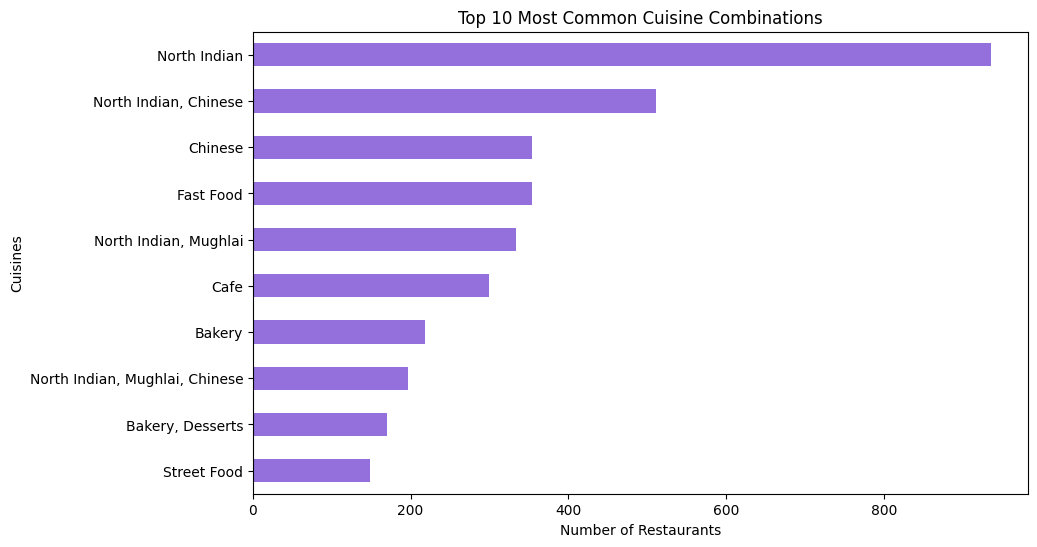

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
cuisine_combo_counts.plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Most Common Cuisine Combinations')
plt.xlabel('Number of Restaurants')
plt.gca().invert_yaxis()
plt.show()

In [11]:
from itertools import combinations

pair_counter = Counter()

for cuisines in df['Cuisines']:
    items = [c.strip() for c in cuisines.split(',')]
    if len(items) > 1:
        for pair in combinations(sorted(items), 2):
            pair_counter[pair] += 1

top_pairs = pair_counter.most_common(10)
print("Top 10 most common cuisine pairs:")
for pair, count in top_pairs:
    print(f"{pair}: {count}")

Top 10 most common cuisine pairs:
('Chinese', 'North Indian'): 1784
('Mughlai', 'North Indian'): 832
('Fast Food', 'North Indian'): 485
('Continental', 'North Indian'): 468
('Chinese', 'Fast Food'): 466
('North Indian', 'South Indian'): 405
('Chinese', 'Mughlai'): 379
('Chinese', 'South Indian'): 346
('Chinese', 'Continental'): 303
('Italian', 'North Indian'): 295


In [12]:
combo_ratings = df.groupby('Cuisines')['Aggregate rating'].agg(['mean', 'count'])
combo_ratings = combo_ratings[combo_ratings['count'] >= 5]  # filter for reliability
combo_ratings = combo_ratings.sort_values('mean', ascending=False)

print("Top 10 highest rated cuisine combinations (min 5 restaurants):")
print(combo_ratings.head(10))

Top 10 highest rated cuisine combinations (min 5 restaurants):
                                           mean  count
Cuisines                                              
North Indian, European, Mediterranean  4.460000      5
Burger                                 4.450000      6
Modern Indian                          4.345455     11
Indian                                 4.250000     18
International                          4.233333      6
Italian, Pizza, Sandwich               4.220000      5
French                                 4.185714      7
Steak                                  4.185714      7
Cafe, Bakery, Desserts                 4.166667      6
Cafe, Italian, Continental             4.150000      6


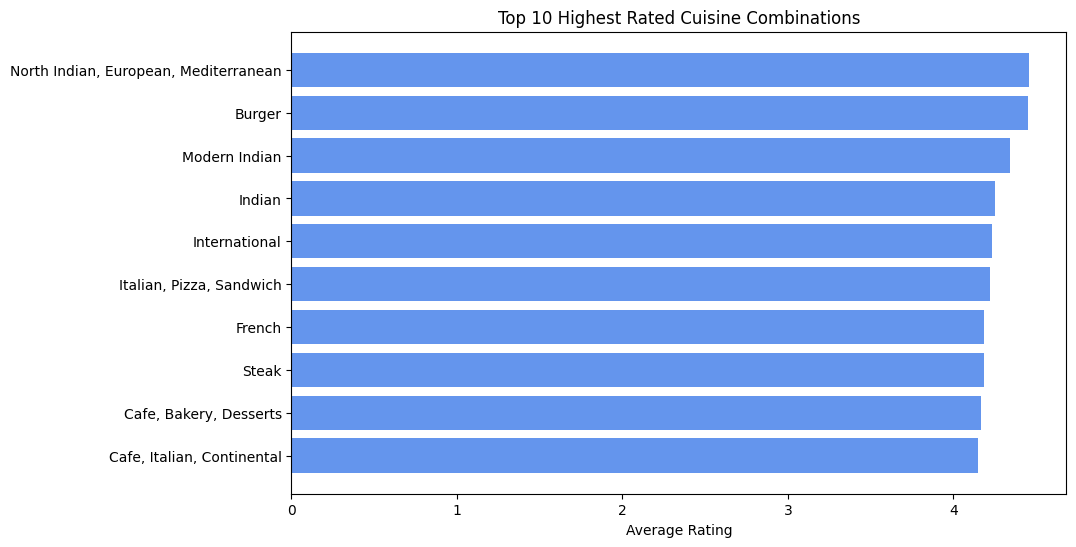

In [13]:
top10 = combo_ratings.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10.index, top10['mean'], color='cornflowerblue')
plt.xlabel('Average Rating')
plt.title('Top 10 Highest Rated Cuisine Combinations')
plt.gca().invert_yaxis()
plt.show()

In [14]:
print("Summary:")
print(f"- Most common cuisine combination: {cuisine_combo_counts.index[0]} ({cuisine_combo_counts.iloc[0]} restaurants)")
print(f"- Highest rated combination (min 5 restaurants): {combo_ratings.index[0]} (avg rating: {combo_ratings['mean'].iloc[0]:.2f})")

Summary:
- Most common cuisine combination: North Indian (936 restaurants)
- Highest rated combination (min 5 restaurants): North Indian, European, Mediterranean (avg rating: 4.46)
